#### Question Statement

## Q.5 V-plot
You can imagine when a protein binds to DNA, then that region will be protected by nucleases (a type of enzyme that cleaves DNA). If you are to plot the protected fragments at protein binding sites, it will take a V-form. Your goal is to show this V-formation using the input data.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [ ]:
# Build a 2D frequency map of fragment center offsets and lengths
frequency = defaultdict(int)

with open('data/Vplot/mapped.bed') as f:
    for line in f:
        cols = line.strip().split('\t')
        # Compute midpoint of the 1st & 2nd interval 
        c1 = (int(cols[2]) + int(cols[3])) // 2 
        c2 = (int(cols[8]) + int(cols[9])) // 2   
        # horizontal offset between the two midpoints
        x = c2 - c1
        # fragment length of the second interval
        y = int(cols[9]) - int(cols[8])
        frequency[(x, y)] += 1

# Prepare lists for heatmap construction
X, Y, Z = [], [], []
for (x, y), count in frequency.items():
    X.append(x)
    Y.append(y)
    Z.append(count)
X_unique = sorted(set(X))
Y_unique = sorted(set(Y))

# Map actual values to matrix indices
XI = {value: idx for idx, value in enumerate(X_unique)}
YI = {value: idx for idx, value in enumerate(Y_unique)}
heatmap = np.zeros((len(Y_unique), len(X_unique)))

# Fill heatmap with counts
for x, y, count in zip(X, Y, Z):
    heatmap[YI[y], XI[x]] = count

PLOTTING

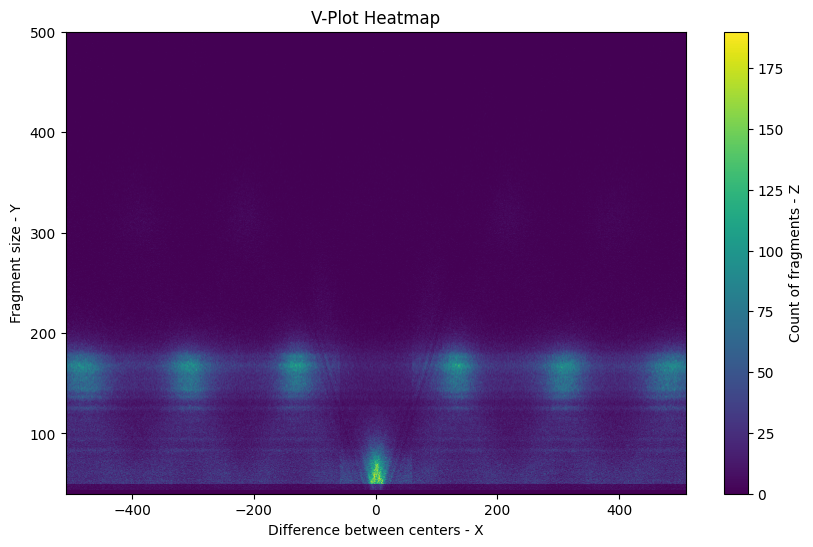

In [4]:
plt.figure(figsize = (10, 6))
plt.imshow(heatmap, aspect='auto', cmap='viridis', origin='lower', extent=[min(X_unique), max(X_unique), min(Y_unique), max(Y_unique)])
plt.title('V-Plot Heatmap')
plt.colorbar(label='Count of fragments - Z')
plt.xlabel('Difference between centers - X')
plt.ylabel('Fragment size - Y')
plt.show()

## Why is a V‑Shape Appearing?

When a protein shields a stretch of DNA:

At the binding site (X ≈ 0), cuts can only happen right outside the protected area, so you mostly recover short fragments.

Moving further out (X ≠ 0), nucleases can cleave at increasingly distant positions, producing progressively longer fragments.

These two trends meet at the binding site, forming the classic V‑shaped plot, with its lowest point marking where the protein sits.

## What This Means

Fragments whose midpoints lie far from X = 0 must be long enough to still span the protected region.

Those centered close to the protein can be much shorter and still overlap.

The shortest possible overlapping fragment defines the V’s tip.